(-0.5, 1023.5, 1023.5, -0.5)

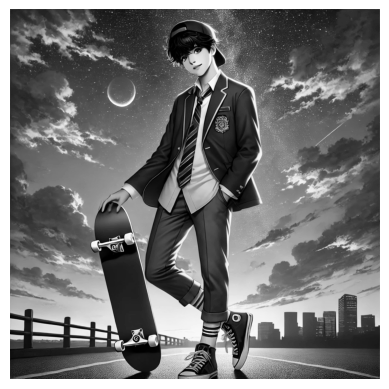

In [1]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread(r"max sc.webp", 0)
plt.imshow( image, cmap='gray')
plt.axis('off')

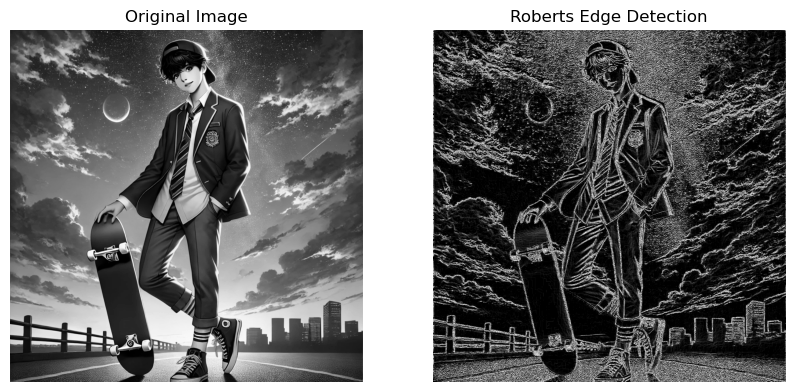

In [2]:
roberts_x = np.array([[1, 0], [0, -1]] ) 
roberts_y = np.array([[0, 1], [-1, 0]] ) 
edges_x = cv2.filter2D(image, -1, roberts_x) 
edges_y = cv2.filter2D(image, -1, roberts_y) 
edges = np.sqrt(edges_x**2 + edges_y**2) 
edges = np.uint8(edges) 
plt.figure(figsize=(10, 5)) 
plt.subplot(1, 2, 1) 
plt.imshow(image, cmap="gray") 
plt.title("Original Image") 
plt.axis("off") 
plt.subplot(1, 2, 2) 
plt.imshow(edges, cmap="gray") 
plt.title("Roberts Edge Detection") 
plt.axis("off") 
plt.show()

(-0.5, 1023.5, 1023.5, -0.5)

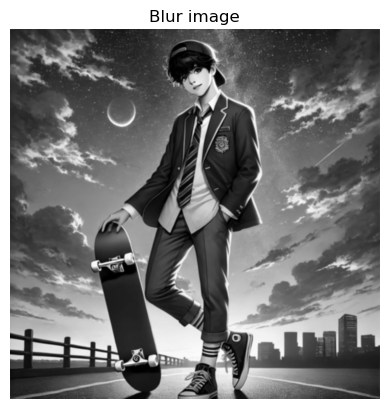

In [3]:
blurred = cv2.GaussianBlur(image, (5, 5), 1.4)  
plt.imshow( blurred , cmap = 'gray' )
plt.title("Blur image")
plt.axis('off')

(-0.5, 1023.5, 1023.5, -0.5)

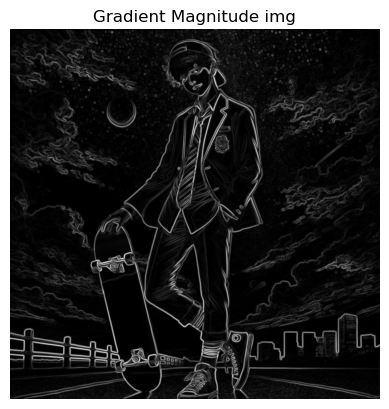

In [4]:
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)   
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)   
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)   
magnitude = np.uint8(magnitude * 255 / np.max(magnitude)) 
gradient_direction = np.arctan2(sobel_y, sobel_x)   
plt.imshow( magnitude , cmap = 'gray' )
plt.title("Gradient Magnitude img")
plt.axis("off")

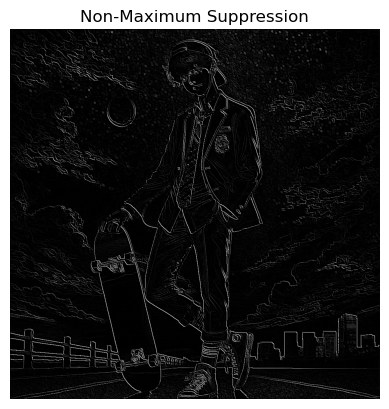

In [16]:
nms_image = simple_nms(magnitude, gradient_direction)
nms_image = cv2.normalize(nms_image, None, 0, 500, cv2.NORM_MINMAX)

plt.imshow(nms_image, cmap="gray")
plt.title("Non-Maximum Suppression")
plt.axis("off")
plt.show()

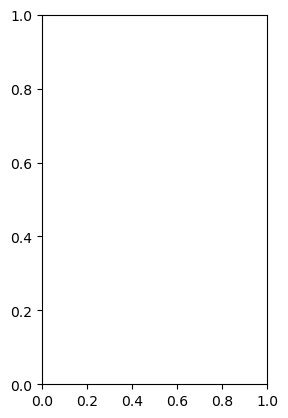

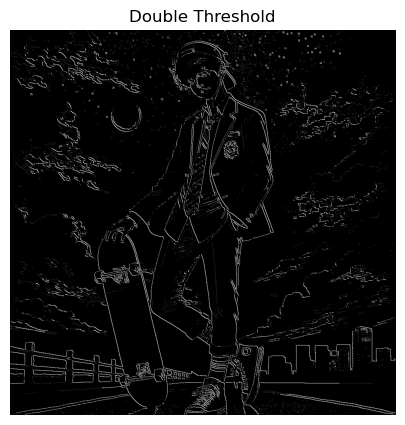

In [44]:
def double_threshold(img, low_thresh, high_thresh):
    thresholded = np.where(img >= high_thresh, 255, np.where(img >= low_thresh, 50, 0))
    return thresholded
low_threshold, high_threshold = 50, 100
thresholded_img = double_threshold(nms_image, low_threshold, high_threshold)
final_edges = canny_edge_detector(nms_image, low_threshold, high_threshold)
plt.subplot(1, 2, 1)
plt.figure(figsize=(10,5))
plt.imshow(thresholded_img, cmap="gray")
plt.title("Double Threshold")
plt.axis("off")
plt.show()

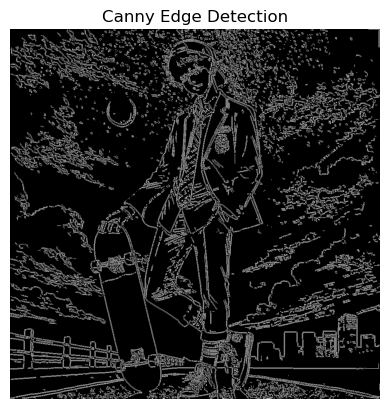

In [32]:
def canny_edge_detector(img, low_thresh, high_thresh):
    return cv2.Canny(img, low_thresh, high_thresh)
plt.imshow(final_edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

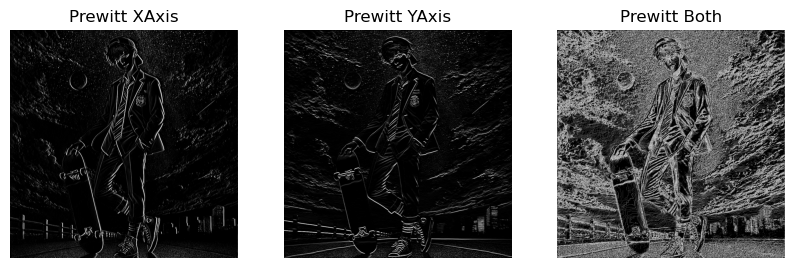

In [70]:
prewitt_x = np.array([[-1, 0, 1],  
                       [-1, 0, 1],  
                       [-1, 0, 1]]) 
prewitt_y = np.array([[-1, -1, -1],  
                       [0, 0, 0],  
                       [1, 1, 1]]) 
edges_x = cv2.filter2D(image, -1, prewitt_x) 
edges_y = cv2.filter2D(image, -1, prewitt_y) 
edges = np.sqrt(edges_x**2 + edges_y**2) 
plt.figure(figsize=(10, 5)) 
plt.subplot(1, 3, 1) 
plt.imshow(edges_x, cmap="gray") 
plt.title("Prewitt XAxis") 
plt.axis("off") 
plt.subplot(1, 3, 2) 
plt.imshow(edges_y, cmap="gray") 
plt.title("Prewitt YAxis") 
plt.axis("off") 
plt.subplot(1, 3, 3) 
plt.imshow(edges, cmap="gray") 
plt.title("Prewitt Both") 
plt.axis("off") 
plt.show()


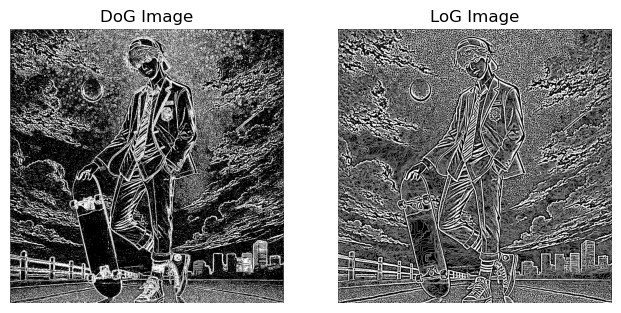

In [74]:
sigma1 = 1.0  
sigma2 = 2.0  
gaussian1 = cv2.GaussianBlur(image, (5, 5), sigma1)
gaussian2 = cv2.GaussianBlur(image, (5, 5), sigma2)
dog_image = gaussian1 - gaussian2
_, dog_threshold = cv2.threshold(dog_image, 10, 255, cv2.THRESH_BINARY)
log_blur = cv2.GaussianBlur(image, (5, 5), 2.0)
log_laplacian = cv2.Laplacian(log_blur, cv2.CV_64F)
_, log_threshold = cv2.threshold(log_laplacian, 0, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(12, 12))
plt.subplot(1, 3, 1), plt.imshow(dog_threshold, cmap='gray'), plt.title('DoG Image')
plt.axis("off")
plt.subplot(1, 3, 2), plt.imshow(log_threshold, cmap='gray'), plt.title('LoG Image')
plt.axis("off")
plt.show()